In [57]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
import mysql.connector
import warnings
warnings.filterwarnings('ignore')


In [25]:
df = pd.read_csv('e commers.csv')
print(df.shape)
print(df.head())

(51289, 16)
        date      Time  Aging  Customer_Id  Gender Device_Type  \
0   1/2/2018  10:56:33    8.0        37077  Female         Web   
1  7/24/2018  20:41:37    2.0        59173  Female         Web   
2  11/8/2018   8:38:49    8.0        41066  Female         Web   
3  4/18/2018  19:28:06    7.0        50741  Female         Web   
4  8/13/2018  21:18:39    9.0        53639  Female         Web   

  Customer_Login_type    Product_Category            Product Sales  Quantity  \
0              Member  Auto & Accessories  Car Media Players   140         1   
1              Member  Auto & Accessories       Car Speakers   211         1   
2              Member  Auto & Accessories    Car Body Covers   117         5   
3              Member  Auto & Accessories    Car & Bike Care   118         1   
4              Member  Auto & Accessories               Tyre   250         1   

   Discount  Profit  Shipping_Cost Order_Priority Payment_method  
0       0.3    46.0            4.6         

In [26]:
df.dtypes

date                       str
Time                       str
Aging                  float64
Customer_Id              int64
Gender                     str
Device_Type                str
Customer_Login_type        str
Product_Category           str
Product                    str
Sales                   object
Quantity                 int64
Discount               float64
Profit                 float64
Shipping_Cost          float64
Order_Priority             str
Payment_method             str
dtype: object

In [27]:

# Fix date column
df['date'] = pd.to_datetime(df['date'])

# Fix time column
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

# Fix Sales column
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Check nulls
print(df.isnull().sum())

date                   0
Time                   0
Aging                  0
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               0
Discount               0
Profit                 0
Shipping_Cost          0
Order_Priority         2
Payment_method         0
dtype: int64


In [28]:
# Drop rows with null values in Sales column no otion to fillna with mean or median 
df["Sales"].dropna(inplace=True)

In [29]:
df.columns.str.strip()

Index(['date', 'Time', 'Aging', 'Customer_Id', 'Gender', 'Device_Type',
       'Customer_Login_type', 'Product_Category', 'Product', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Order_Priority',
       'Payment_method'],
      dtype='str')

In [30]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Month_Name'] = df['date'].dt.strftime('%B')

print(df['Year'].value_counts())
print(df['Month_Name'].value_counts())

Year
2018    51289
Name: count, dtype: int64
Month_Name
November     5679
May          5416
July         5321
December     5064
October      4886
September    4851
August       4373
June         4179
April        3896
March        2899
January      2519
February     2206
Name: count, dtype: int64


In [31]:
print("Total Revenue:", df['Sales'].sum().round(2))
print("Total Profit:", df['Profit'].sum().round(2))
print("Total Orders:", df.shape[0])
print("Unique Customers:", df['Customer_Id'].nunique())
print("Product Categories:", df['Product_Category'].nunique())
print("\nAvg Order Value:", df['Sales'].mean().round(2))
print("Avg Profit per Order:", df['Profit'].mean().round(2))


Total Revenue: 7813271.0
Total Profit: 3611130.8
Total Orders: 51289
Unique Customers: 38997
Product Categories: 4

Avg Order Value: 152.34
Avg Profit per Order: 70.41


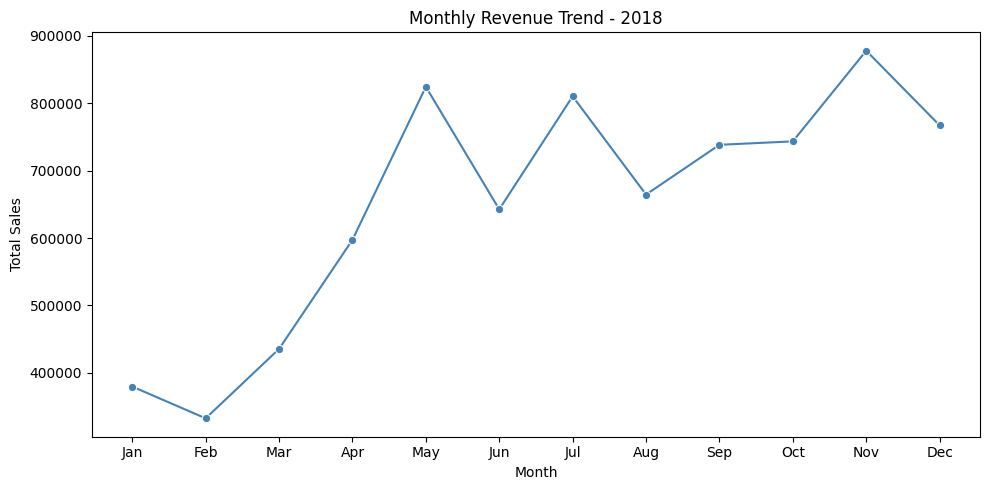

In [32]:
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby('Month')['Sales'].sum().sort_index()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='steelblue')
plt.title('Monthly Revenue Trend - 2018')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

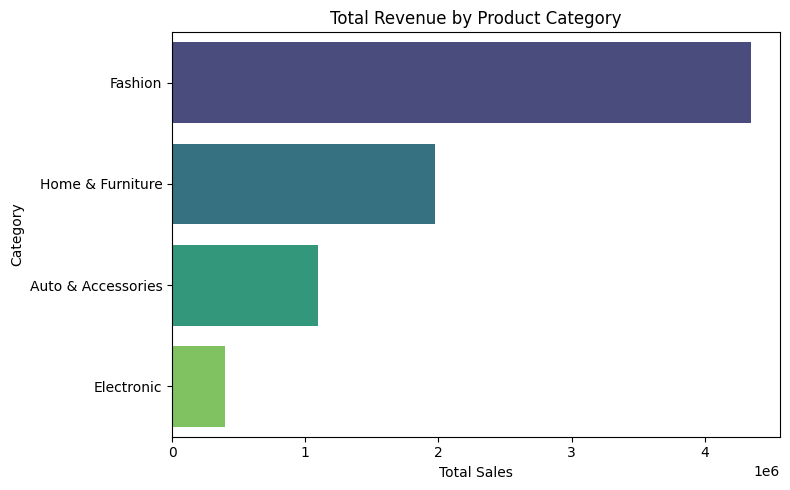

In [33]:
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

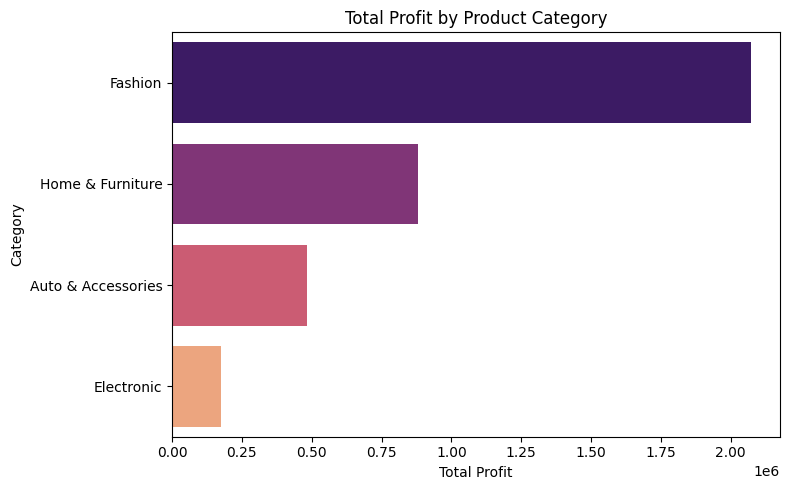

In [34]:
plt.figure(figsize=(8, 5))
category_profit = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.values, y=category_profit.index, palette='magma')
plt.title('Total Profit by Product Category')
plt.xlabel('Total Profit')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_profit.png')
plt.show()

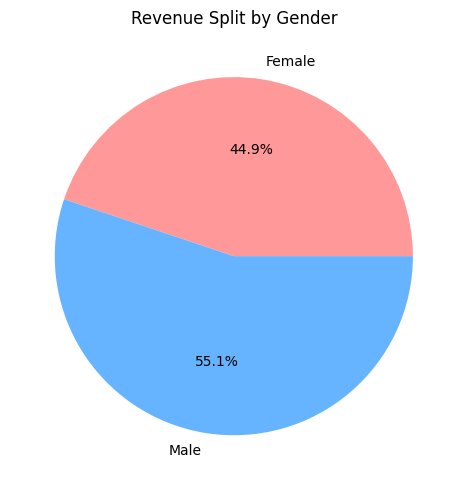

In [35]:
plt.figure(figsize=(8, 5))
gender_sales = df.groupby('Gender')['Sales'].sum()
plt.pie(gender_sales.values, labels=gender_sales.index, 
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Revenue Split by Gender')
plt.tight_layout()
#plt.savefig('gender_sales.png')
plt.show()

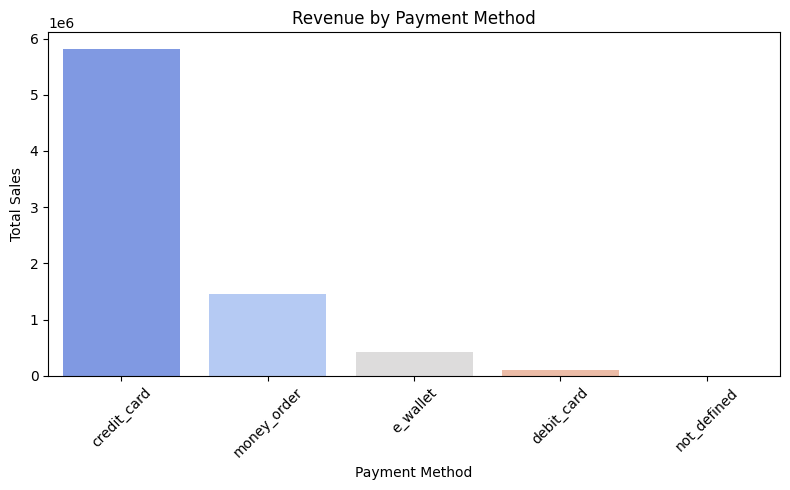

In [36]:
plt.figure(figsize=(8, 5))
payment = df.groupby('Payment_method')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=payment.index, y=payment.values, palette='coolwarm')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('payment_sales.png')
plt.show()

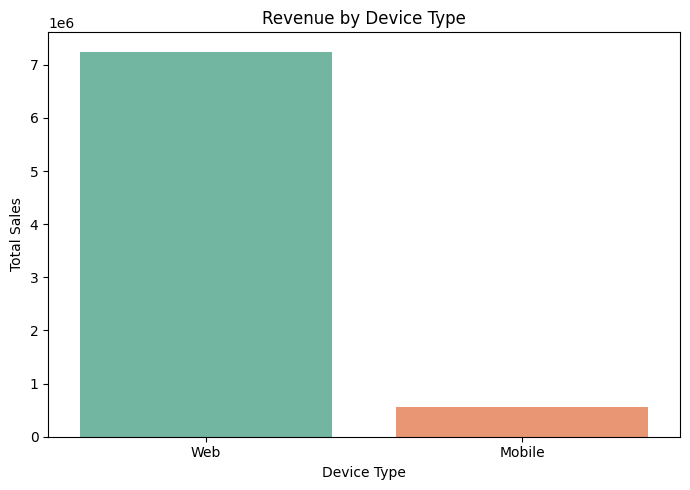

In [37]:
plt.figure(figsize=(7, 5))
device = df.groupby('Device_Type')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=device.index, y=device.values, palette='Set2')
plt.title('Revenue by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('device_sales.png')
plt.show()

In [38]:
# Standardize column names to lowercase
df.columns = df.columns.str.lower()

In [39]:
# Connection details
user = 'root'
password = '9718'
host = '127.0.0.1'
port = 3306
database = 'E-Commerce'

try:
    # Create engine
    engine = create_engine(
        f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
    )

    print("Connected successfully to MySQL")
    print("-" * 50)

    # Use DataFrame directly (NO CSV)
    cleaned_df = df.copy()

    # Basic validation
    print("Rows to insert:", cleaned_df.shape[0])

    if cleaned_df.empty:
        raise ValueError("DataFrame is empty. Nothing to insert.")

    print("Loading data to MySQL...")

    # Fast insert
    cleaned_df.to_sql(
        'ecommerce_data',
        con=engine,
        if_exists='replace',
        index=False,
        chunksize=5000,
        method='multi'
    )

    # Verify insert


    print("Data loaded successfully to MySQL")

except Exception as e:
    print("Error:", e)

Error: No module named 'pymysql'


In [41]:
# Connection details
user = 'root'
password = '9718'
host = '127.0.0.1'
port = 3306
database = 'E-Commerce'

try:
    # Create engine
    engine = create_engine(
        f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
    )

    print("Connected successfully to MySQL")
    print("-" * 50)

    # Use DataFrame directly (NO CSV)
    cleaned_df = df.copy()

    # Basic validation
    print("Rows to insert:", cleaned_df.shape[0])

    if cleaned_df.empty:
        raise ValueError("DataFrame is empty. Nothing to insert.")

    print("Loading data to MySQL...")

    # Fast insert
    cleaned_df.to_sql(
        'ecommerce_data',
        con=engine,
        if_exists='replace',
        index=False,
        chunksize=5000,
        method='multi'
    )

    # Verify insert


    print("Data loaded successfully to MySQL")

except Exception as e:
    print("Error:", e)

Connected successfully to MySQL
--------------------------------------------------
Rows to insert: 51289
Loading data to MySQL...
Data loaded successfully to MySQL


In [71]:

def execute_query(query):
    connection = None
    cursor = None
    try:
        connection = mysql.connector.connect(
            host="127.0.0.1",
            user="root",
            password="9718",
            database="E_Commerce"
        )

        cursor = connection.cursor()
        cursor.execute(query)

        # Handle SELECT vs others
        if query.strip().lower().startswith("select"):
            result = cursor.fetchall()
            df = pd.DataFrame(result, columns=[col[0] for col in cursor.description])
            return df
        else:
            connection.commit()
            return "Query executed successfully"

    except mysql.connector.Error as e:
        raise Exception(f"Database error: {e}")

    finally:
        if cursor:
            cursor.close()
        if connection:
            connection.close()

In [ ]:
execute_query("""
SELECT
    product_category,
    SUM(sales) AS Total_Revenue
FROM
    ecommerce_data
GROUP BY
    product_category
""");")